# Experiments -- PCA vs Autoencoder on S&P 500 log returns

Each cell below runs one experiment, saves its CSV under `results/` and
its plot under `plots/`, and overlays the result on a shared figure where
applicable. The data is loaded ONCE at the top so every experiment sees
the same train/test split and the same train-only standardisation.

**Architecture knobs (edit per-cell to override the defaults from
`src.autoencoder`):**
- `encoder_hidden` / `decoder_hidden` -- lists of hidden-layer sizes
- `activation` -- one of `'sigmoid'`, `'relu'`, `'tanh'`
- `component_grid` -- the list of bottleneck sizes k to sweep

## Setup

In [1]:
import os

from src import data as data_mod
from src import pca as pca_mod
from src import autoencoder as ae_mod
from src import plotting as plotting_mod
from src.plotting import PLOTS_DIR

plotting_mod.setup_style()

RESULTS_DIR = 'results/'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,   exist_ok=True)

# Shared dataset for every experiment in this notebook.
data = data_mod.prepare_data()
print(f'X_train: {data["X_train"].shape}, X_test: {data["X_test"].shape}, d={data["d"]}')
print(f'device for AE: {ae_mod.DEVICE}')

X_train: (1006, 470), X_test: (252, 470), d=470
device for AE: cuda


## 1. PCA on its own
Sweeps `n_components` over the shared component grid.

[PCA] k=  1  train R^2=0.3254  test R^2=0.1472  train MSE=0.6746  test MSE=0.7329
[PCA] k=  2  train R^2=0.3819  test R^2=0.1901  train MSE=0.6181  test MSE=0.6961
[PCA] k=  4  train R^2=0.4281  test R^2=0.2306  train MSE=0.5719  test MSE=0.6613
[PCA] k=  8  train R^2=0.4767  test R^2=0.2924  train MSE=0.5233  test MSE=0.6082
[PCA] k= 16  train R^2=0.5313  test R^2=0.3323  train MSE=0.4687  test MSE=0.5738
[PCA] k= 32  train R^2=0.5977  test R^2=0.3807  train MSE=0.4023  test MSE=0.5322


,train_preserved_variance,test_preserved_variance,residual_entropy,train_mse,test_mse
k,,,,,
1,0.325400,0.147232,402.881189,0.674599,0.732879
2,0.381876,0.190067,399.822358,0.618124,0.696066
4,0.428107,0.230569,394.635452,0.571892,0.661258
8,0.476681,0.292357,385.489208,0.523319,0.608157
16,0.531321,0.332343,369.529149,0.468678,0.573792
32,0.597729,0.380733,341.534872,0.402271,0.532206


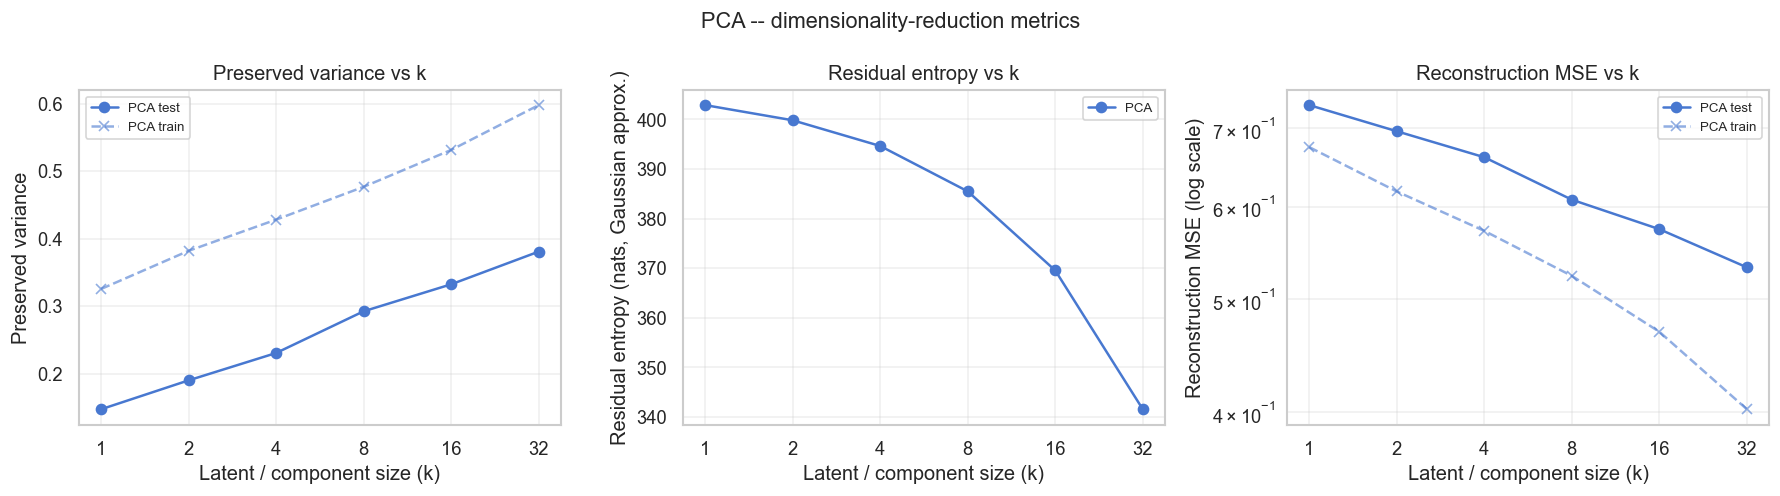

In [2]:
pca_results = pca_mod.run_pca_experiment(
    data,
    component_grid=pca_mod.COMPONENT_GRID,
)
pca_results.to_csv(RESULTS_DIR + 'pca_experiments.csv', float_format='%.6f')

plotting_mod.plot_experiments_comparison(
    {'PCA': pca_results},
    title='PCA -- dimensionality-reduction metrics',
    save_path=PLOTS_DIR + 'plot_pca_experiments.png',
)
pca_results.round(6)

## 2. Autoencoder on its own
Default architecture is `[d, 64, k, 64, d]` with sigmoid activations.
Change `encoder_hidden`, `decoder_hidden`, or `activation` here to try a different model.

[AE/relu] k=  1  training [470, 64, 1, 64, 470] ...
[AE/relu] k=  1  train R^2=0.2604  test R^2=0.0960  train MSE=0.7396  test MSE=0.7769
[AE/relu] k=  2  training [470, 64, 2, 64, 470] ...
[AE/relu] k=  2  train R^2=0.3823  test R^2=0.1803  train MSE=0.6177  test MSE=0.7045
[AE/relu] k=  4  training [470, 64, 4, 64, 470] ...
[AE/relu] k=  4  train R^2=0.4281  test R^2=0.2110  train MSE=0.5719  test MSE=0.6781
[AE/relu] k=  8  training [470, 64, 8, 64, 470] ...
[AE/relu] k=  8  train R^2=0.4771  test R^2=0.2584  train MSE=0.5229  test MSE=0.6373
[AE/relu] k= 16  training [470, 64, 16, 64, 470] ...
[AE/relu] k= 16  train R^2=0.5207  test R^2=0.2977  train MSE=0.4793  test MSE=0.6036
[AE/relu] k= 32  training [470, 64, 32, 64, 470] ...
[AE/relu] k= 32  train R^2=0.5654  test R^2=0.3182  train MSE=0.4346  test MSE=0.5860


,train_preserved_variance,test_preserved_variance,residual_entropy,train_mse,test_mse
k,,,,,
1,0.260392,0.096024,406.735830,0.739608,0.776888
2,0.382294,0.180294,400.060278,0.617706,0.704465
4,0.428104,0.211020,394.767682,0.571896,0.678058
8,0.477078,0.258426,384.661530,0.522922,0.637317
16,0.520697,0.297687,368.627509,0.479303,0.603576
32,0.565376,0.318175,348.844139,0.434624,0.585968


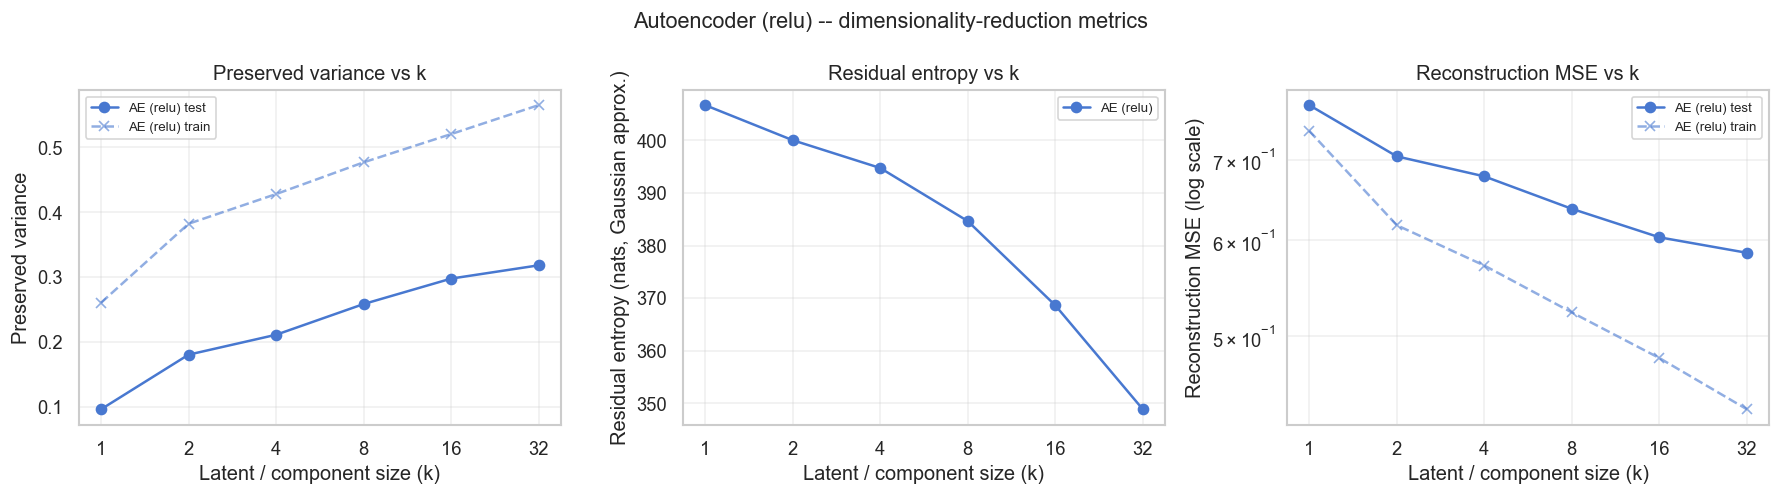

In [8]:
encoder_hidden = [64]
decoder_hidden = [64]
activation     = 'relu'

ae_results = ae_mod.run_ae_experiment(
    data,
    component_grid=ae_mod.COMPONENT_GRID,
    encoder_hidden=encoder_hidden,
    decoder_hidden=decoder_hidden,
    activation=activation,
)
ae_results.to_csv(RESULTS_DIR + f'autoencoder_experiments_{activation}.csv', float_format='%.6f')

plotting_mod.plot_experiments_comparison(
    {f'AE ({activation})': ae_results},
    title=f'Autoencoder ({activation}) -- dimensionality-reduction metrics',
    save_path=PLOTS_DIR + f'plot_autoencoder_experiments_{activation}.png',
)
ae_results.round(6)

## 3. PCA vs Autoencoder
Overlays the two methods on a single figure. Colour = method, linestyle = split.

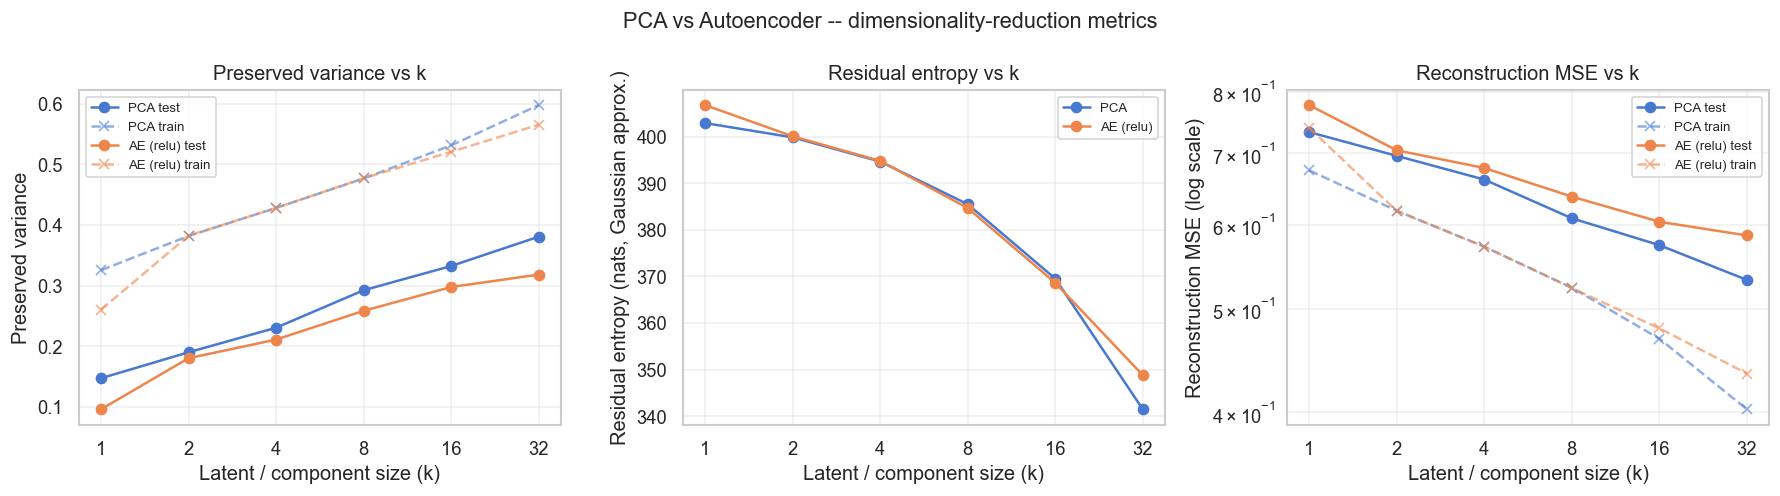

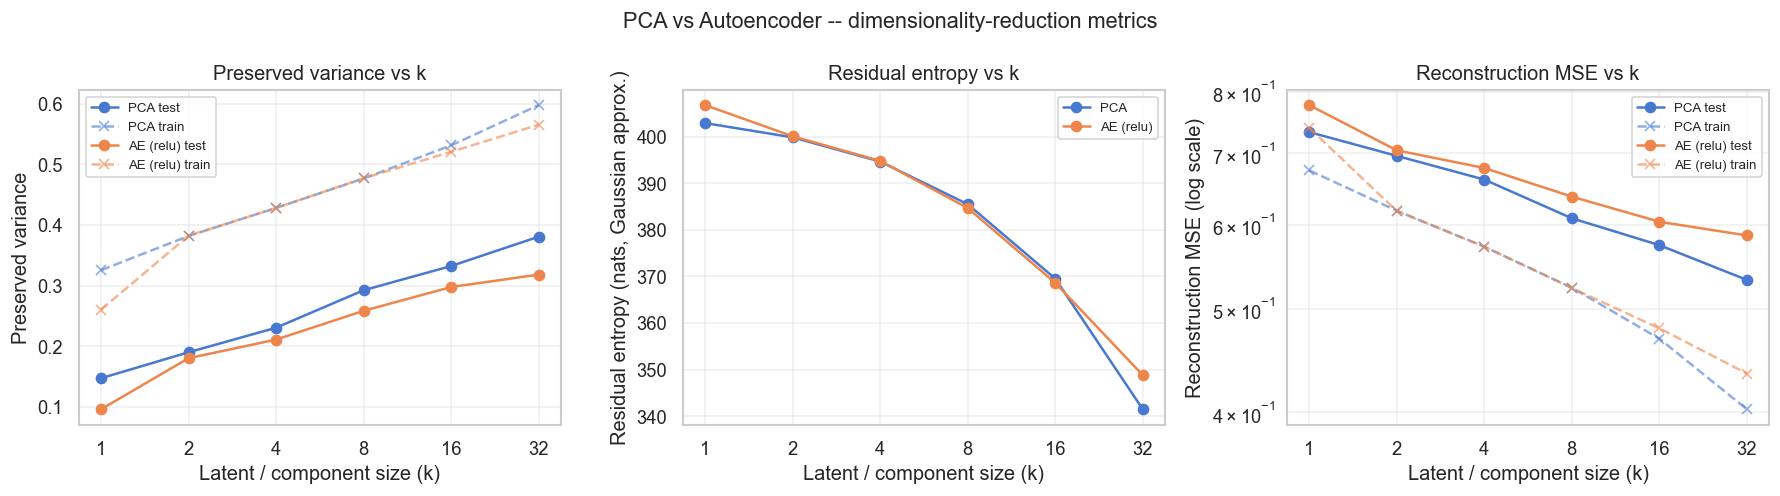

In [9]:
# Re-uses the results from sections 1 and 2 -- no retraining.
plotting_mod.plot_experiments_comparison(
    {'PCA': pca_results, f'AE ({activation})': ae_results},
    title='PCA vs Autoencoder -- dimensionality-reduction metrics',
    save_path=PLOTS_DIR + 'plot_combined_experiments.png',
)

## 4. Autoencoder activation sweep
Trains the same architecture with sigmoid / relu / tanh and overlays them.


=== activation: sigmoid ===
[AE/sigmoid] k=  1  training [470, 64, 1, 64, 470] ...
[AE/sigmoid] k=  1  train R^2=0.3081  test R^2=0.1106  train MSE=0.6919  test MSE=0.7643
[AE/sigmoid] k=  2  training [470, 64, 2, 64, 470] ...
[AE/sigmoid] k=  2  train R^2=0.3669  test R^2=0.1289  train MSE=0.6331  test MSE=0.7487
[AE/sigmoid] k=  4  training [470, 64, 4, 64, 470] ...
[AE/sigmoid] k=  4  train R^2=0.3866  test R^2=0.1336  train MSE=0.6134  test MSE=0.7446
[AE/sigmoid] k=  8  training [470, 64, 8, 64, 470] ...
[AE/sigmoid] k=  8  train R^2=0.4125  test R^2=0.1588  train MSE=0.5875  test MSE=0.7230
[AE/sigmoid] k= 16  training [470, 64, 16, 64, 470] ...
[AE/sigmoid] k= 16  train R^2=0.4661  test R^2=0.2248  train MSE=0.5339  test MSE=0.6662
[AE/sigmoid] k= 32  training [470, 64, 32, 64, 470] ...
[AE/sigmoid] k= 32  train R^2=0.5039  test R^2=0.2563  train MSE=0.4961  test MSE=0.6392

=== activation: relu ===
[AE/relu] k=  1  training [470, 64, 1, 64, 470] ...
[AE/relu] k=  1  train R^2=

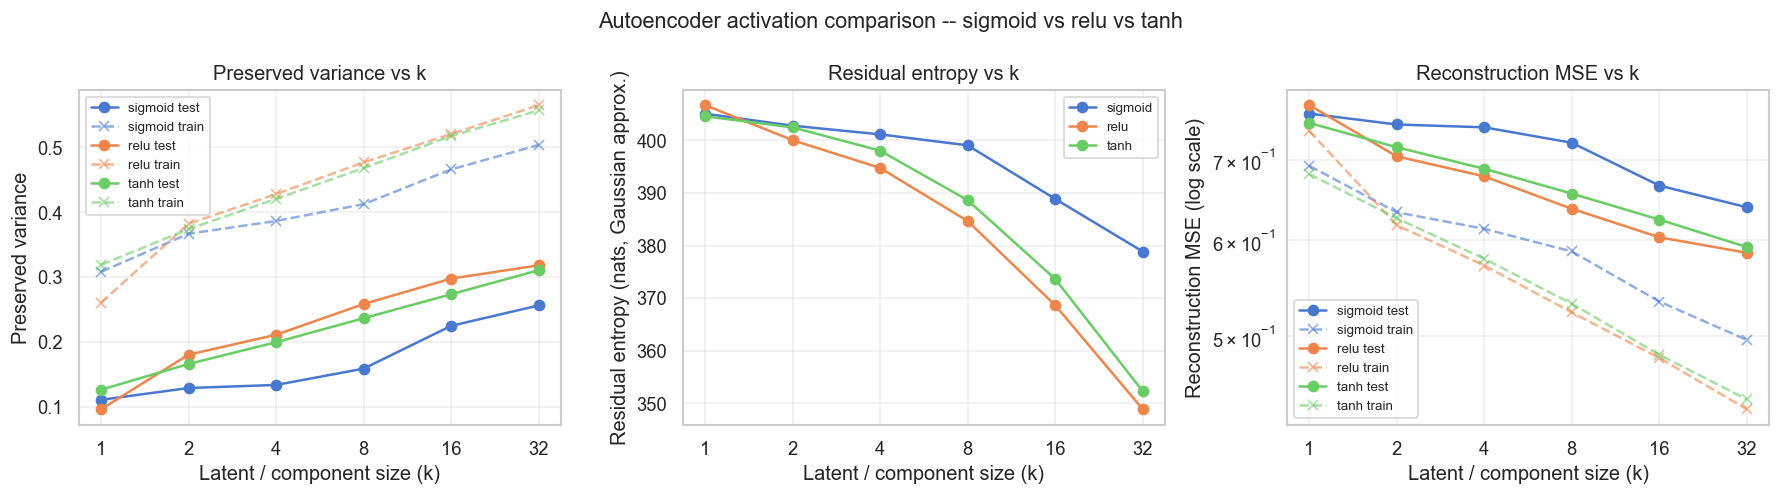

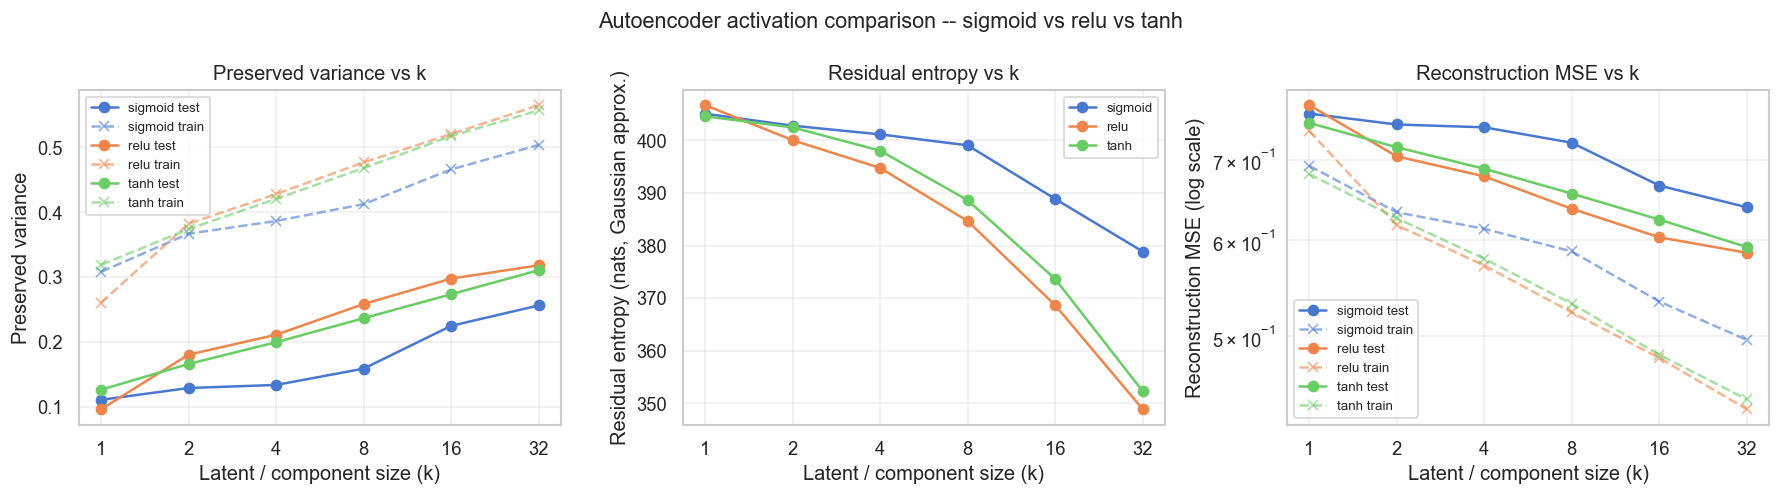

In [5]:
encoder_hidden = [64]
decoder_hidden = [64]

activation_results = {}
for act in ['sigmoid', 'relu', 'tanh']:
    print(f'\n=== activation: {act} ===')
    df = ae_mod.run_ae_experiment(
        data,
        component_grid=ae_mod.COMPONENT_GRID,
        encoder_hidden=encoder_hidden,
        decoder_hidden=decoder_hidden,
        activation=act,
    )
    df.to_csv(RESULTS_DIR + f'autoencoder_experiments_{act}.csv', float_format='%.6f')
    activation_results[act] = df

plotting_mod.plot_experiments_comparison(
    activation_results,
    title='Autoencoder activation comparison -- sigmoid vs relu vs tanh',
    save_path=PLOTS_DIR + 'plot_activation_comparison.png',
)

## 5. Autoencoder architecture sweep
Compare several encoder/decoder shapes on one figure. Add or remove entries in the
`architectures` dict below to change which ones are run.


=== architecture [64] ===
[AE/relu] k=  1  training [470, 64, 1, 64, 470] ...
[AE/relu] k=  1  train R^2=0.2604  test R^2=0.0960  train MSE=0.7396  test MSE=0.7769
[AE/relu] k=  2  training [470, 64, 2, 64, 470] ...
[AE/relu] k=  2  train R^2=0.3823  test R^2=0.1803  train MSE=0.6177  test MSE=0.7045
[AE/relu] k=  4  training [470, 64, 4, 64, 470] ...
[AE/relu] k=  4  train R^2=0.4281  test R^2=0.2110  train MSE=0.5719  test MSE=0.6781
[AE/relu] k=  8  training [470, 64, 8, 64, 470] ...
[AE/relu] k=  8  train R^2=0.4771  test R^2=0.2584  train MSE=0.5229  test MSE=0.6373
[AE/relu] k= 16  training [470, 64, 16, 64, 470] ...
[AE/relu] k= 16  train R^2=0.5207  test R^2=0.2977  train MSE=0.4793  test MSE=0.6036
[AE/relu] k= 32  training [470, 64, 32, 64, 470] ...
[AE/relu] k= 32  train R^2=0.5654  test R^2=0.3182  train MSE=0.4346  test MSE=0.5860

=== architecture [128, 64] ===
[AE/relu] k=  1  training [470, 128, 64, 1, 64, 128, 470] ...
[AE/relu] k=  1  train R^2=0.3200  test R^2=0.125

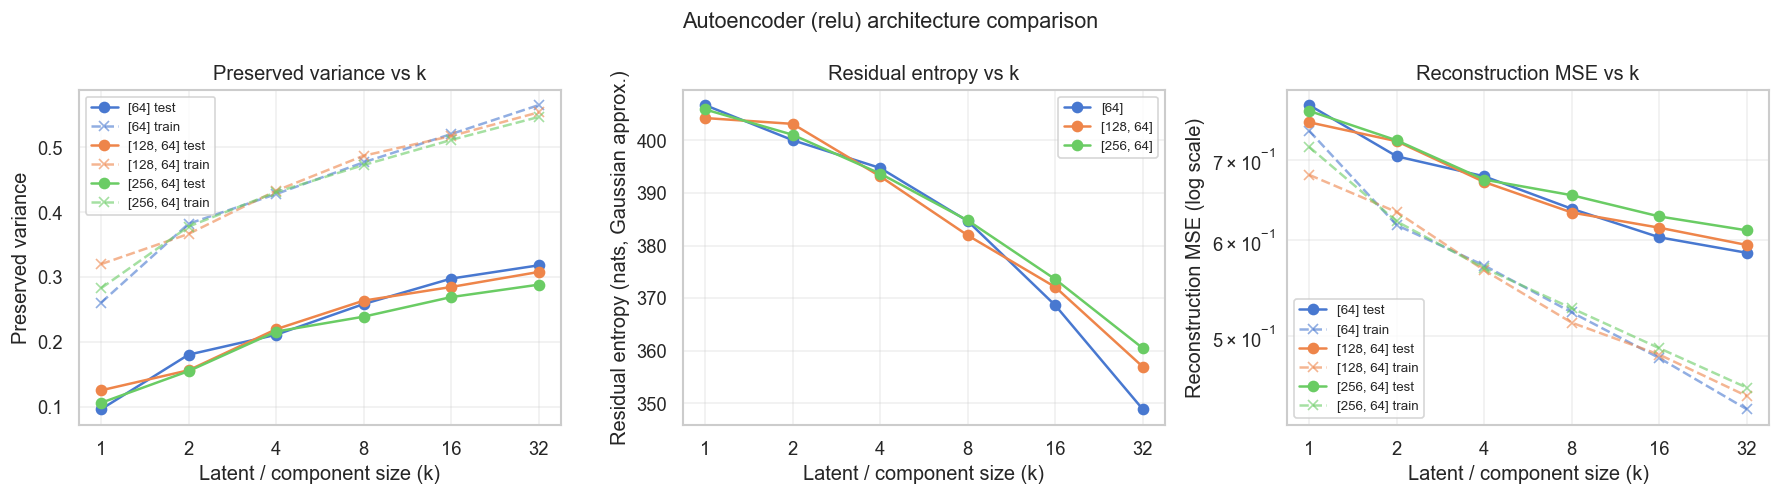

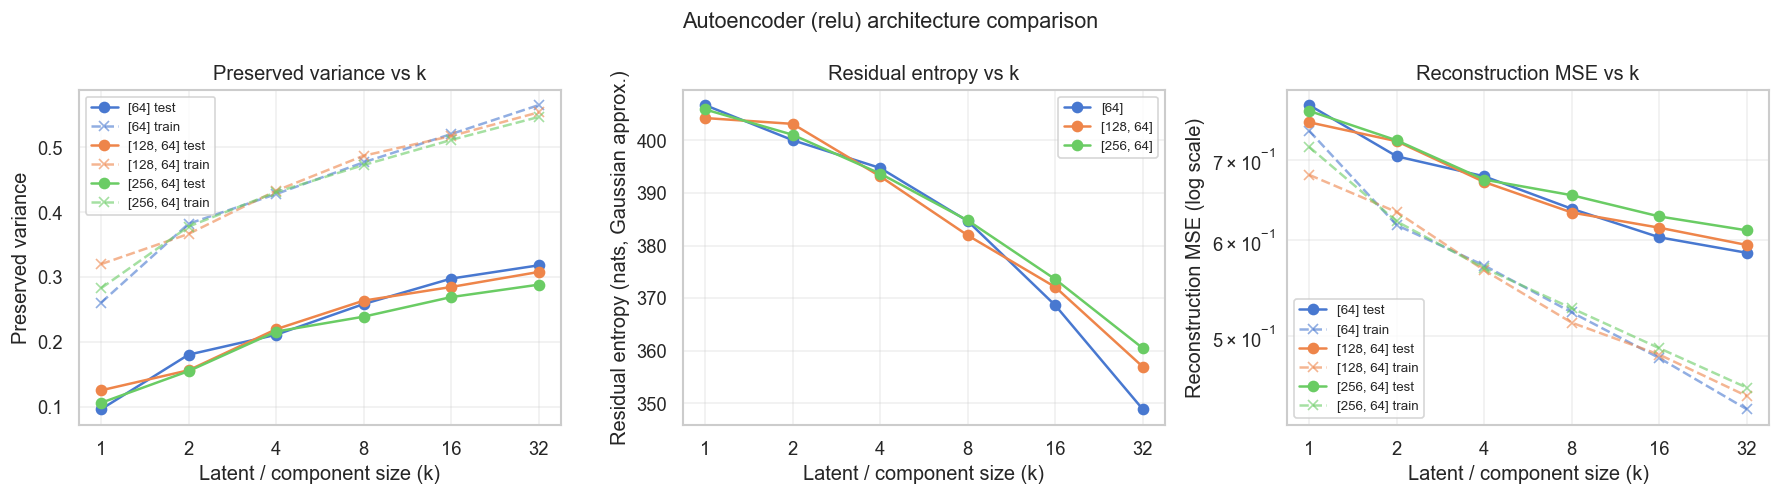

In [6]:
architectures = {
    '[64]':         {'encoder_hidden': [64],       'decoder_hidden': [64]},
    '[128, 64]':    {'encoder_hidden': [128, 64],  'decoder_hidden': [64, 128]},
    '[256, 64]':    {'encoder_hidden': [256, 64],  'decoder_hidden': [64, 256]},
}
activation = 'relu'

architecture_results = {}
for label, arch in architectures.items():
    print(f'\n=== architecture {label} ===')
    df = ae_mod.run_ae_experiment(
        data,
        component_grid=ae_mod.COMPONENT_GRID,
        activation=activation,
        **arch,
    )
    safe = label.replace(' ', '').replace(',', '_').replace('[', '').replace(']', '')
    df.to_csv(RESULTS_DIR + f'autoencoder_arch_{safe}.csv', float_format='%.6f')
    architecture_results[label] = df

plotting_mod.plot_experiments_comparison(
    architecture_results,
    title=f'Autoencoder ({activation}) architecture comparison',
    save_path=PLOTS_DIR + 'plot_architecture_comparison.png',
)

## 6. Summary table
Test-split numbers for every experiment computed in this notebook.

In [7]:
import pandas as pd

summary = {'PCA': pca_results, f'AE ({activation})': ae_results}
summary.update({f'AE {act}': df for act, df in activation_results.items()})
summary.update({f'AE arch {label}': df for label, df in architecture_results.items()})

summary_table = pd.concat(
    {label: df[['test_preserved_variance', 'residual_entropy', 'test_mse']]
     for label, df in summary.items()},
    axis=1,
)
summary_table.round(6)

PCA                                          AE (relu)  \
   test_preserved_variance residual_entropy  test_mse test_preserved_variance   
k                                                                               
1                 0.147232       402.881189  0.732879                0.110625   
2                 0.190067       399.822358  0.696066                0.128858   
4                 0.230569       394.635452  0.661258                0.133573   
8                 0.292357       385.489208  0.608157                0.158762   
16                0.332343       369.529149  0.573792                0.224771   
32                0.380733       341.534872  0.532206                0.256273   

                                           AE sigmoid                   \
   residual_entropy  test_mse test_preserved_variance residual_entropy   
k                                                                        
1        405.090676  0.764339                0.110625       405.090676   
2        402.815370  0.748670                0.128858       402.815370   
4        401.161986  0.744617                0.133573       401.161986   
8        399.075284  0.722970                0.158762       399.075284   
16       388.872158  0.666241                0.224771       388.872158   
32       378.857716  0.639167                0.256273       378.857716   

                             AE relu  ...   AE tanh            AE arch [64]  \
    test_mse test_preserved_variance  ...  test_mse test_preserved_variance   
k                                     ...                                     
1   0.764339                0.096024  ...  0.750907                0.096024   
2   0.748670                0.180294  ...  0.716804                0.180294   
4   0.744617                0.211020  ...  0.687929                0.211020   
8   0.722970                0.258426  ...  0.656116                0.258426   
16  0.666241                0.297687  ...  0.624294                0.297687   
32  0.639167                0.318175  ...  0.592434                0.318175   

                                    AE arch [128, 64]                   \
   residual_entropy  test_mse test_preserved_variance residual_entropy   
k                                                                        
1        406.735830  0.776888                0.125245       404.273750   
2        400.060278  0.704465                0.156245       403.164532   
4        394.767682  0.678058                0.219559       393.176165   
8        384.661530  0.637317                0.263680       381.945061   
16       368.627509  0.603576                0.284723       372.104281   
32       348.844139  0.585968                0.307929       356.933932   

                   AE arch [256, 64]                             
    test_mse test_preserved_variance residual_entropy  test_mse  
k                                                                
1   0.751775                0.105992       405.910884  0.768321  
2   0.725133                0.154939       401.090591  0.726255  
4   0.670720                0.215935       393.695625  0.673835  
8   0.632802                0.238941       384.787276  0.654063  
16  0.614718                0.269165       373.587293  0.628089  
32  0.594774                0.288328       360.467788  0.611619  

[6 rows x 24 columns]